# Prever a evasão e o sucesso acadêmico dos alunos
Um título bom é sempre muito interessante. Descreva aqui sobre o que é o seu trabalho e porque ele é importante. É quase um abstract/resumo de um artigo.

Usamos geralmente o site Kaggle pra pegar os dados e estudar eles. Pra não precisar de uma burocracia pra baixar arquivo e pra deixar o código mais limpo e organizado, a gente pode instalar a biblioteca _kagglehub_ no nosso computador e pegar os dados que a gente quiser via código mesmo. Pra isso, rode o código a seguir. Ele só precisa ser rodado uma vez por máquina

In [ ]:
!pip install kagglehub 

Agora importamos a biblioteca em si e pegamos os dados que queremos. Vou usar o que o tio passou pra vocês. Quando você clica pra baixar o arquivo no site da Kaggle, eles te dão esse código abaixo. Ele baixa o arquivo e te mostra onde que ele tá no seu computador.

In [4]:
import kagglehub

# Download latest version
tabela_teste_1 = kagglehub.dataset_download("thedevastator/higher-education-predictors-of-student-retention")

print("Path to dataset files:", tabela_teste_1)

Path to dataset files: C:\Users\Fernanda\.cache\kagglehub\datasets\thedevastator\higher-education-predictors-of-student-retention\versions\2


Se você não tiver a fim de importar coisas dessa forma (ou se você estiver trabalhando com arquivos fora da Kaggle, você pode pegar suas tabelas assim também), você pode usar a biblioteca do pandas pra fazer a leitura da sua tabela. Vamos começar a colocar a mão na massa com o pandas.

o import pandas as pd faz a importação da biblioteca Pandas e dá um apelido mais fácil pra ela, o _pd_. Depois fazemos uma variável receber a função _pd.read_csv("nome_do_arquivo.csv")_, que retorna a tabela que ela tá lendo. Lembre que o arquivo ipnyb que você tá programando e o arquivo csv tem que estar na mesma pasta pra fazer desse jeito. Rode o código e o jupyter notebook vai te mostrar a tabela completa. Pra mim, o nome tá _dataset.csv_, então colocarei isso na minha função

In [25]:
# Importando biblioteca
import pandas as pd

# Display da Tabela
df = pd.read_csv("dataset.csv")
display(df) # nunca cometa o pecado de usar print, pfv

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,15,1,1,1,1,1,6,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,15,1,1,19,1,1,10,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,12,1,1,1,22,27,10,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9,1,1,1,22,27,8,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


Vamos criar um mapa de calor de veja a correlação das variáveis com o fator "saiu ou não da faculdade". O texto todo tá em números, exceto a coluna Target. Vamos dar um valor 1 para onde for Dropout e 0 para onde for Graduate, pra que consigamos calcular a correlação. Pra isso, a gente precisa da biblioteca numpy. Ela lida com "condicionais em tabelas".

In [26]:
# Renomeando coluna Target

import numpy as np

# 1. Transformamos o texto da evasão em números (1 para Evasão, 0 para os demais)
# (Se a sua coluna tiver outro nome em vez de 'Target', basta trocar aqui)
df['Target'] = np.where(df['Target'] == 'Dropout', 1, 0)

# A leitura é: na tabela df, vamos mexer na coluna Target. Onde na coluna Target tiver escrito Dropout, vamos trocar para 1.
# Se estiver escrito qualquer outra coisa, colocamos 0 (se dropout, 1, se não, 0)

# Vamos ver como ficou
display(df['Target'])

0       1
1       0
2       1
3       0
4       0
       ..
4419    0
4420    1
4421    1
4422    0
4423    0
Name: Target, Length: 4424, dtype: int64

Para desenhar os gráficos, usamos a ajuda de outras bibliotecas. O matplotlib cria e apresenta a "figura gráfico" e o sns deixa você estilizar em tipos de gráficos diferentões

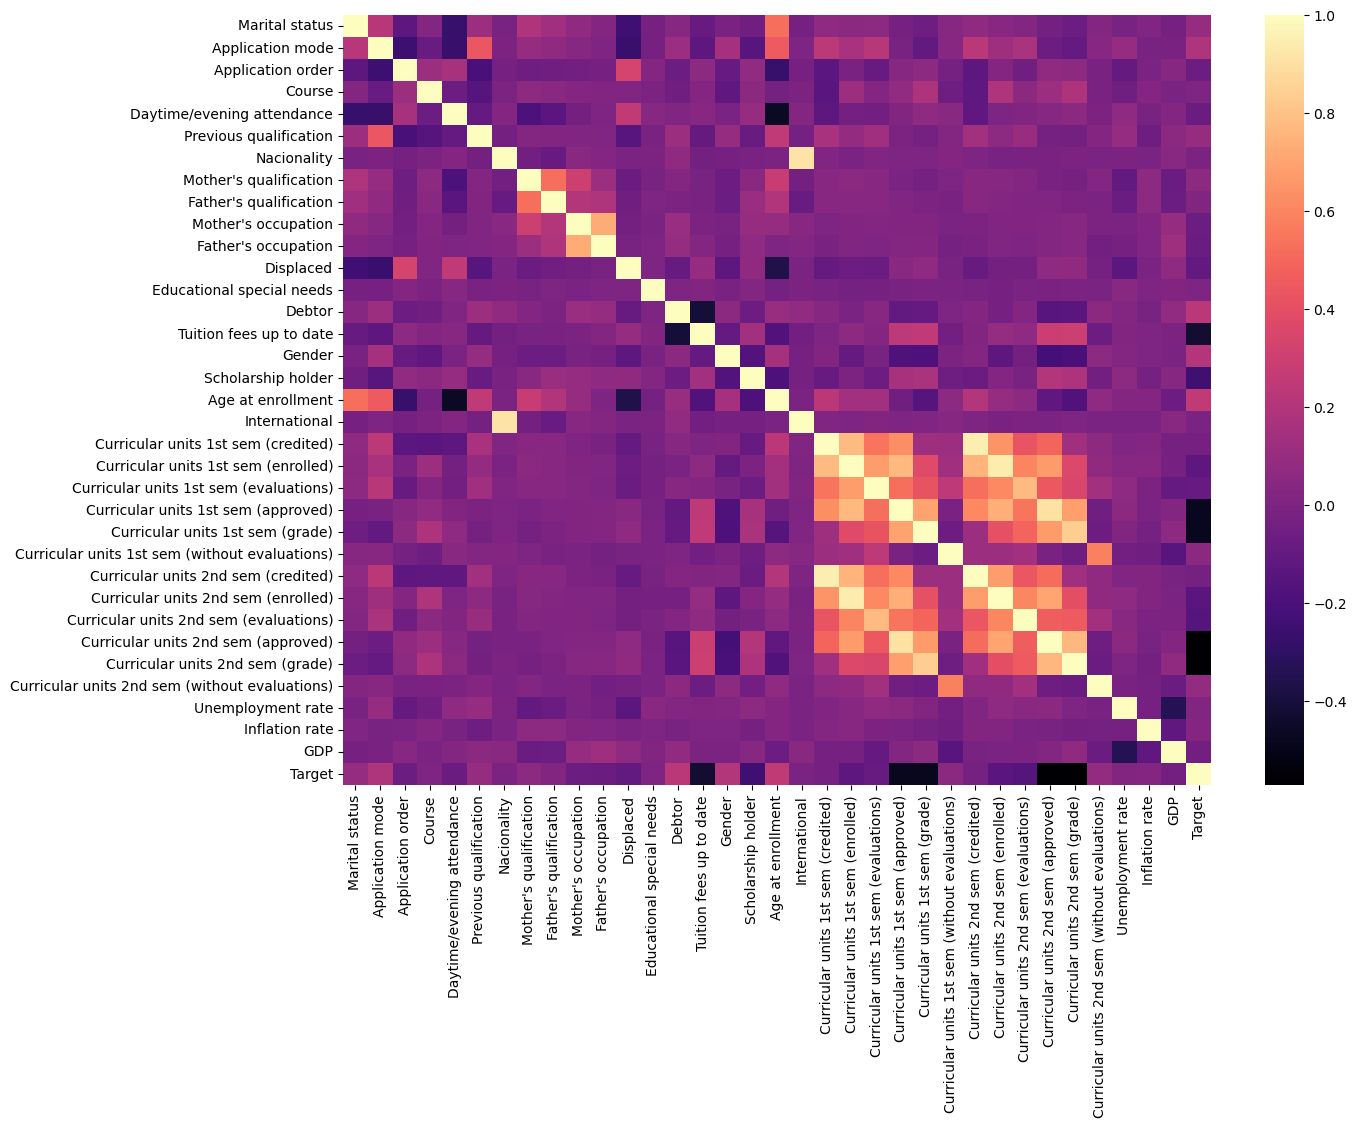

Target                                            1.000000
Age at enrollment                                 0.254215
Debtor                                            0.229407
Gender                                            0.203983
Application mode                                  0.188908
Marital status                                    0.093712
Previous qualification                            0.091590
Curricular units 2nd sem (without evaluations)    0.079901
Mother's qualification                            0.059499
Curricular units 1st sem (without evaluations)    0.054230
Inflation rate                                    0.027826
Father's qualification                            0.016267
Unemployment rate                                 0.012980
Educational special needs                         0.002806
Course                                           -0.000083
Nacionality                                      -0.001571
International                                    -0.0103

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Calculamos a correlação ignorando qualquer texto residual
# calcule a correlação da tabela somente onde tiver números
correlacao = df.corr(numeric_only=True)

# 3. Geramos o Mapa de Calor
plt.figure(figsize=(14, 10)) # cria a figura
sns.heatmap(correlacao, annot=False, cmap='magma') # (dados, se é pra anotar número dentro do bloquinho, paleta de cores)
plt.savefig('heatmap_evasao.png', dpi=300, bbox_inches='tight') # baixa a figura do mapa
plt.show() # mostra o gráfico criado na tela

# (Bônus) Vendo o ranking numérico direto para a nossa nova coluna de Evasão
print(correlacao['Target'].sort_values(ascending=False))

A leitura do gráfico é feita da seguinte maneira:
1. Quadrados pretos indicam uma correlação negativa muito grande. Em outras palavras, quando essa variável sobe muito, a evasão cai
    - Olha a linha que cruza "Target" e "Tuition fees up to date". Significa que quem paga em dia, não sai da escola
    - Em Scholarship Holder, quem tem bolsa, tem muito poucas chances de sair da faculdade
2. Quadrados mais claros indicam uma correlação mais positiva. Quando essa variável sobe, a evasão também sobe
    - Em "Age at enrollment", entende-se que estudantes que entram na faculdade mais novos, deixam a faculdade mais fácil
    - Em "Debtor", alunos com dívidas são mais propensos a ter evasão

E por aí vai